In [9]:
from sklearn.svm import SVC
from model_evaluation import EvalConfig, EvalModel
from sklearn import svm
from sklearn.svm import LinearSVC
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from feature_engineering.create_dtw_distances import create_dtw_distances, DTWFeatureGenerator

import os
os.mkdir('Data/DTWFeatures')

%matplotlib inline

In [10]:
def train_test_split_df(old_csv_path, train_csv=None, test_csv=None, test_size=0.3, random_state=42):
    old_df = pd.read_csv(old_csv_path)
    train_df, test_df = train_test_split(old_df, test_size=test_size, random_state=random_state)
    if train_csv:
        train_df.to_csv(train_csv, index=False)
        print(f'saved train df to {train_csv}')
    if test_csv:
        test_df.to_csv(test_csv, index=False)
        print(f'saved test df to {test_csv}')
    return train_df, test_df


old_csv = 'Data/features_30_sec.csv'
train_csv_path = 'Data/DTWFeatures/train.csv'
test_csv_path = 'Data/DTWFeatures/test.csv'
train_df, test_df = train_test_split_df(old_csv, train_csv=train_csv_path, test_csv=test_csv_path)

saved train df to Data/DTWFeatures/train.csv
saved test df to Data/DTWFeatures/test.csv


In [11]:
generator = DTWFeatureGenerator(dist_type='rms', downsample_factor=5)
generator.fit(train_df)
new_train_df = generator.transform(train_df)
new_test_df = generator.transform(test_df)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/699 [00:00<?, ?it/s]

  0%|          | 0/699 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

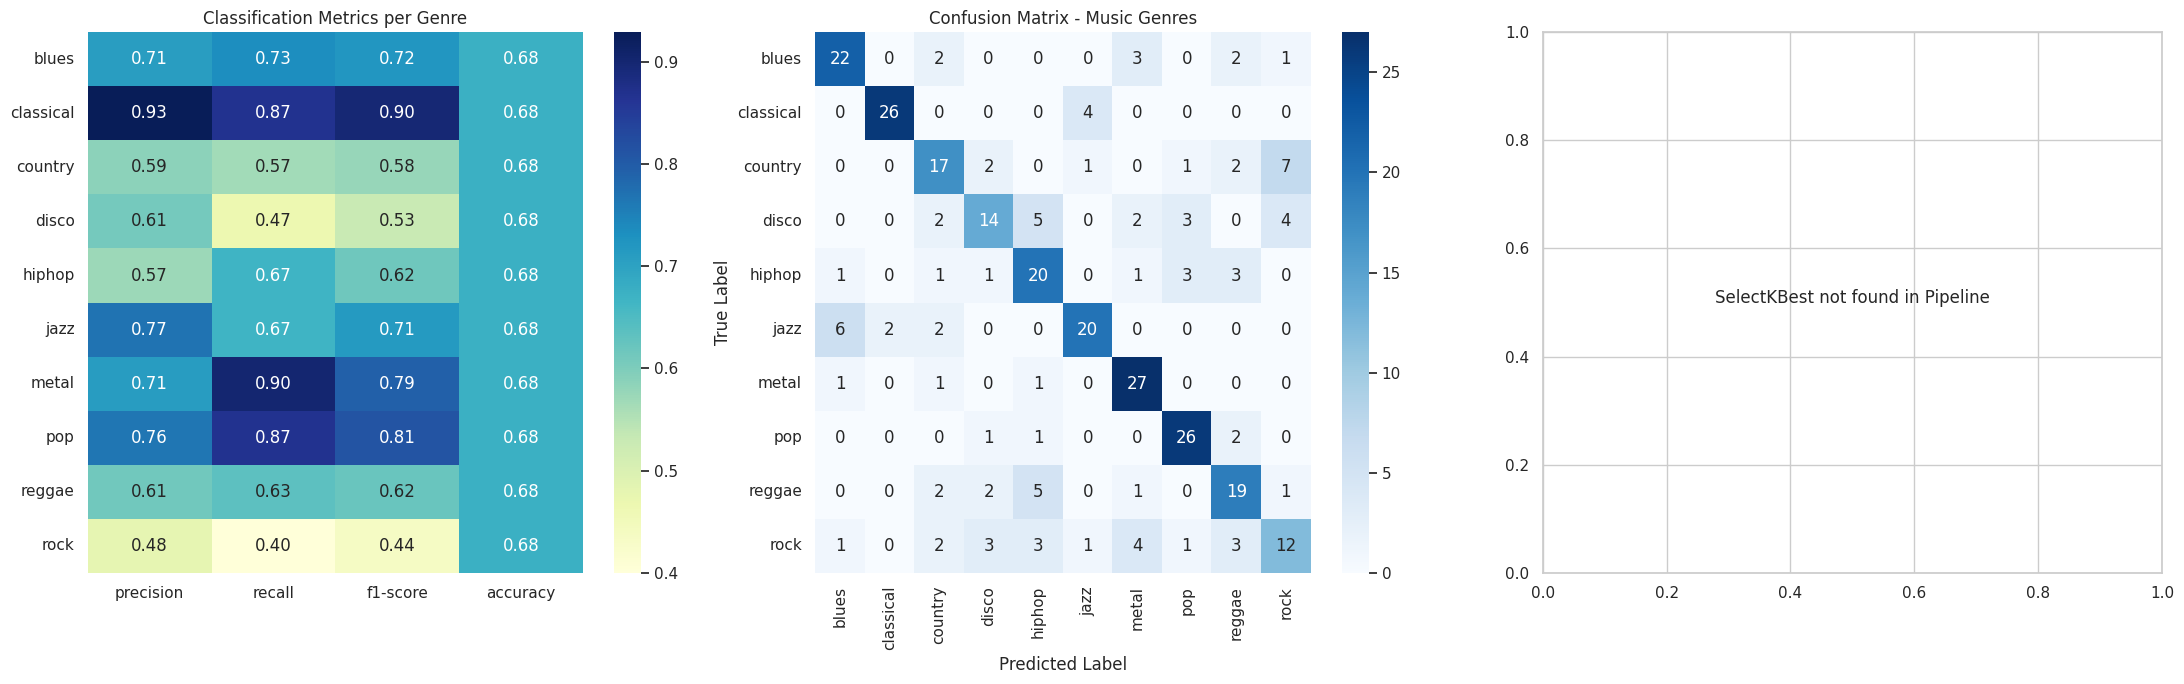

In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    #('select_best', SelectKBest(f_classif, k=5)),
    ("clf", LogisticRegression(C=1.0)),
])

config = EvalConfig(
    csv_path="Data/extra_features_30_sec.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

res = EvalModel(config)

res.evaluate()
res.plot_eval()